In [1]:
import os

from datetime import datetime
current_time = datetime.now()
time_str = current_time.strftime("%Y_%m_%d_%H_%M_%S")

data_name = "iris"
root_folder = ".."
results_root_folder = root_folder + os.sep + "results"
algorithm_id = f"Basic{data_name}Basic_{time_str}"
dataset_root = root_folder + os.sep + "dataset"

In [2]:
from mofgbmlpy.utility.parallel_cross_validation import run_cross_validation


args = [
    "--data-name", data_name,
    "--rand-seed", "2020",
    "--terminate-evaluation", "10000",
    "--objectives", "num-rules", "error-rate",
    "--algorithm-id", algorithm_id,
    "--root-folder", results_root_folder,
    "--algorithm", "nsga2"
]

run_cross_validation(args, dataset_root)

Running cross-validation experiments: 100%|██████████| 30/30 [00:53<00:00,  1.78s/ experiment]


Execution time: 53.70


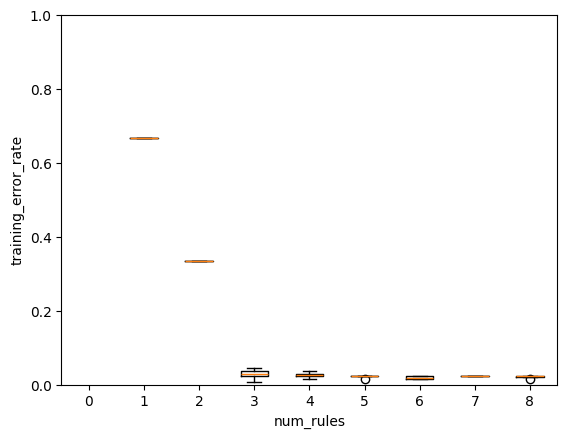

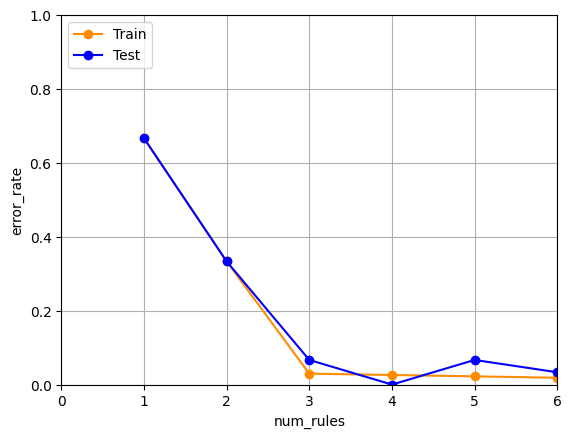

In [3]:
from mofgbmlpy.utility.parallel_cross_validation import show_results_median_line_plot, get_results, show_results_box_plot

results = get_results(results_root_folder, algorithm_id, data_name)
results_solutions = [run["solutions"] for run in results]
show_results_box_plot(results_solutions, x_key="num_rules", remove_rare_solutions=False)
show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=False, xlim=[0,6])